# Load Data Set

In [24]:
%pip install matplotlib seaborn numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("data/raw/Airbnb_Open_Data.csv")

df_viz = df.copy()




C:\Users\Dunith Munasinghe\AppData\Local\Temp\ipykernel_2952\2684931962.py:6: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/raw/Airbnb_Open_Data.csv")


# Basic Distribution Check

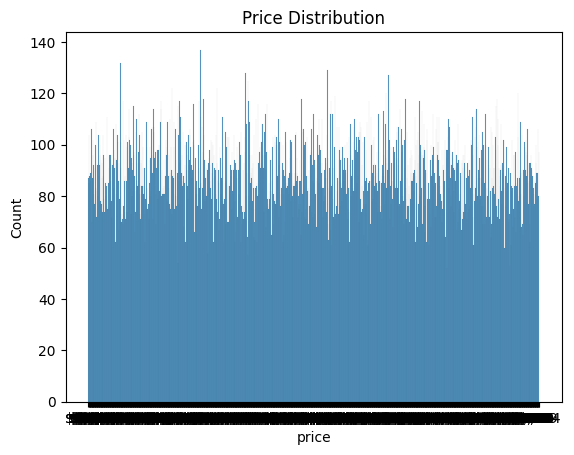

In [26]:
# Price distribution
plt.figure()
sns.histplot(df_viz['price'], bins=50)
plt.title("Price Distribution")
plt.show()

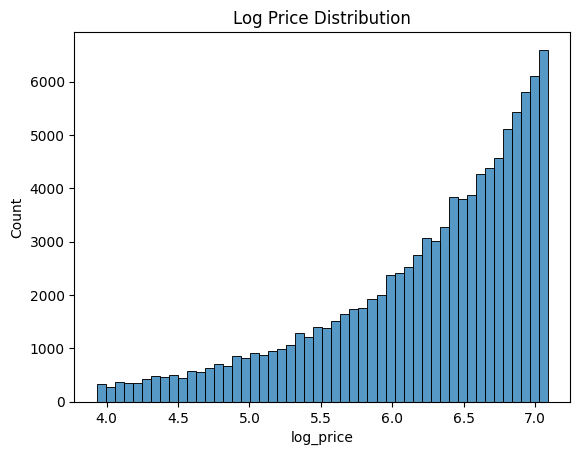

In [28]:
df_viz["price"] = (
    df_viz["price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df_viz["price"] = pd.to_numeric(df_viz["price"], errors="coerce")
df_viz["price"] = df_viz["price"].fillna(df_viz["price"].median())

df_viz["log_price"] = np.log1p(df_viz["price"])

plt.figure()
sns.histplot(df_viz["log_price"], bins=50)
plt.title("Log Price Distribution")
plt.show()

# Demand Signals Distribution

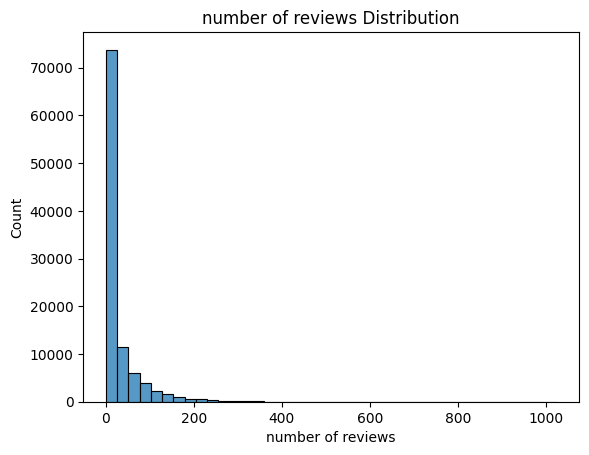

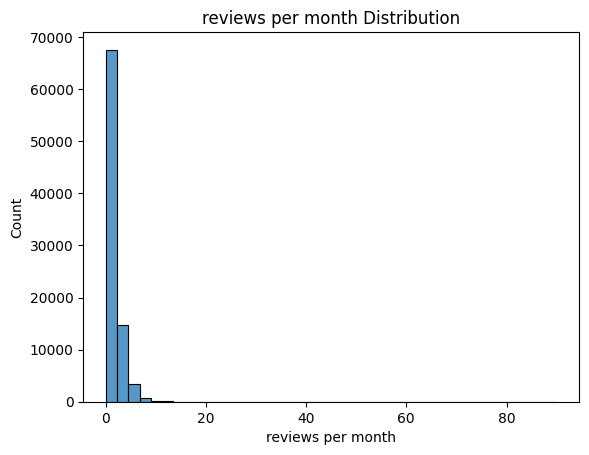

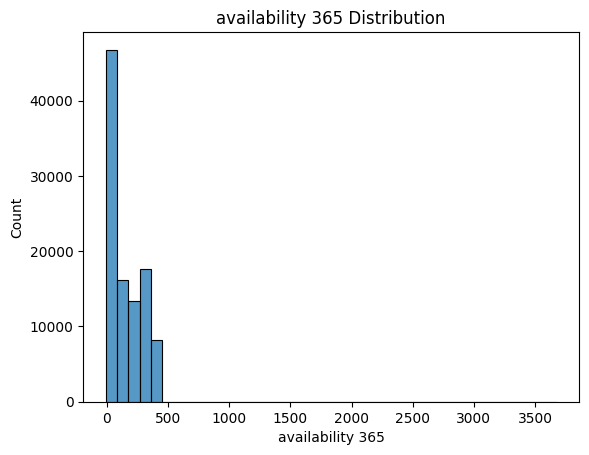

In [33]:
cols = ['number of reviews', 'reviews per month', 'availability 365']

for col in cols:
    plt.figure()
    sns.histplot(df_viz[col], bins=40)
    plt.title(f"{col} Distribution")
    plt.show()

# Price vs Demand

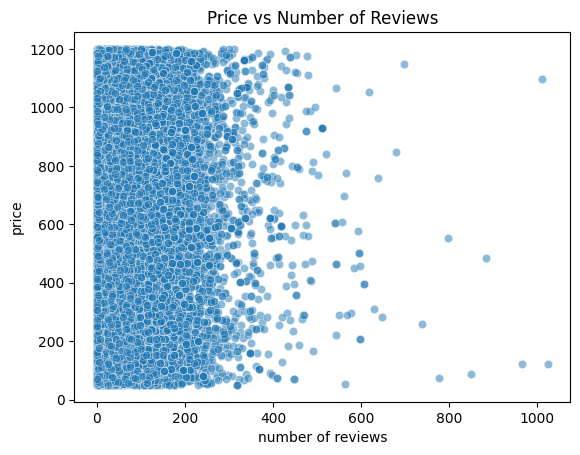

In [35]:
plt.figure()
sns.scatterplot(
    x='number of reviews',
    y='price',
    data=df_viz,
    alpha=0.5
)
plt.title("Price vs Number of Reviews")
plt.show()

# Availability vs Demand

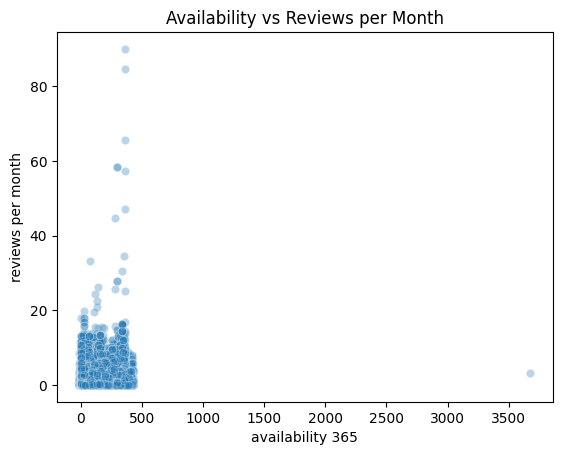

In [36]:
plt.figure()
sns.scatterplot(
    x='availability 365',
    y='reviews per month',
    data=df_viz,
    alpha=0.3
)
plt.title("Availability vs Reviews per Month")
plt.show()

# Room Type vs Price

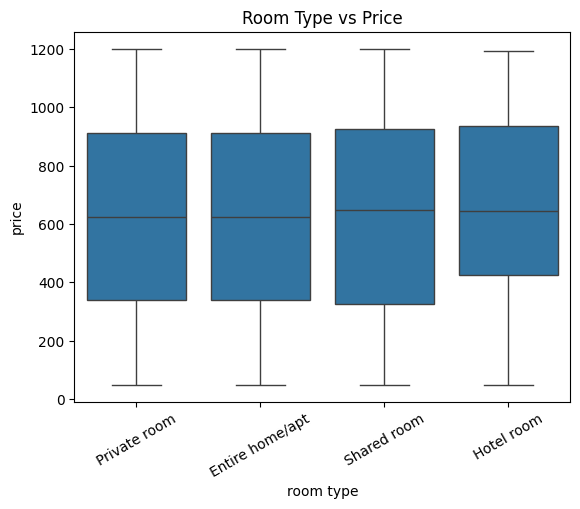

In [37]:
plt.figure()
sns.boxplot(
    x='room type',
    y='price',
    data=df_viz
)
plt.xticks(rotation=30)
plt.title("Room Type vs Price")
plt.show()

# Neighbourhood Group Impact

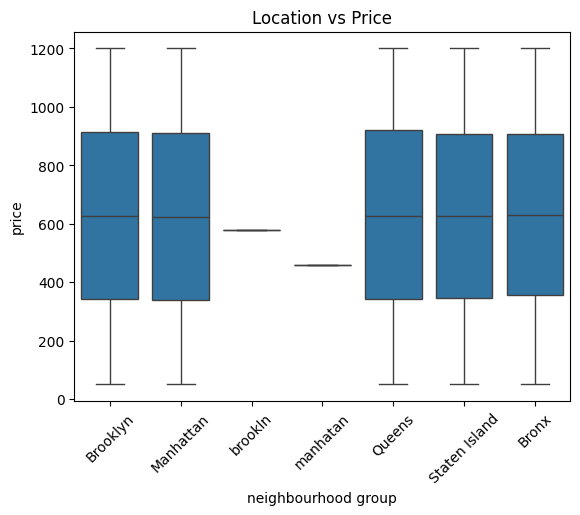

In [39]:
plt.figure()
sns.boxplot(
    x='neighbourhood group',
    y='price',
    data=df_viz
)
plt.xticks(rotation=45)
plt.title("Location vs Price")
plt.show()

# Correlation Heatmap

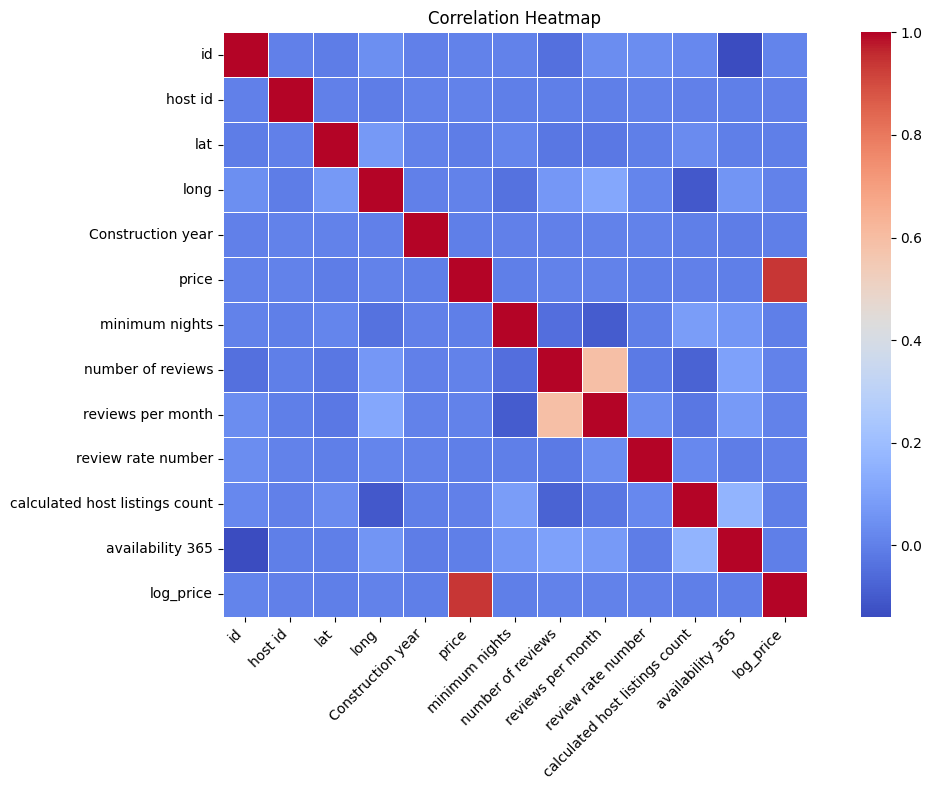

In [43]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df_viz.corr(numeric_only=True),
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


# Outlier Detection

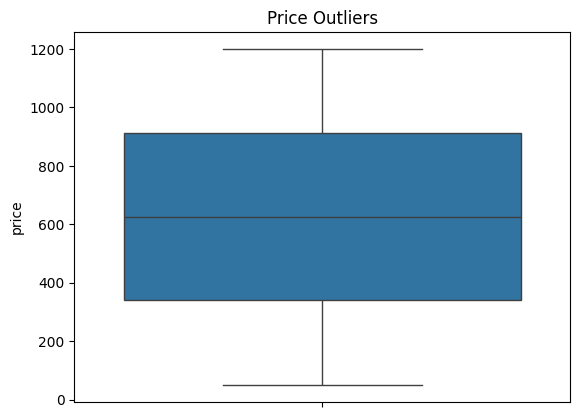

In [44]:
plt.figure()
sns.boxplot(y=df_viz['price'])
plt.title("Price Outliers")
plt.show()